In [ ]:
!pip install Keras-Preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.6 MB/s eta 0:00:00


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
import json
import nltk

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D, Bidirectional, GlobalMaxPool1D, Conv1D
from tensorflow.keras.utils import to_categorical

import plotly as py
import cufflinks as cf
from plotly.offline import iplot
py.offline.init_notebook_mode(connected=True)
cf.go_offline()


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df=pd.read_csv('/content/15k_English.csv')

In [ ]:
newdf = df.copy()

In [ ]:
df.head()

,review,sentiment
0,Two companies have given shoes,Negative
1,Keeps warm and uncomfortable at times,Neutral
2,"I ordered 2 ton size, got that size,, my AC si...",Positive
3,So far so good. What kind of service is given ...,Negative
4,very bad,Negative


In [ ]:
df["sentiment"].unique()

array(['Negative', 'Neutral', 'Positive'], dtype=object)

In [ ]:
df.shape

(15034, 2)

In [ ]:
print("Total Comment:",len(df),
      "\nTotal Negative :",len(df[df.sentiment =='Negative']),
      "\nTotal Positive :",len(df[df.sentiment=='Positive']),
      "\nTotal Neutral :",len(df[df.sentiment=='Neutral']))

Total Comment: 15034 
Total Negative : 5066 
Total Positive : 5147 
Total Neutral : 4821


In [ ]:
import os

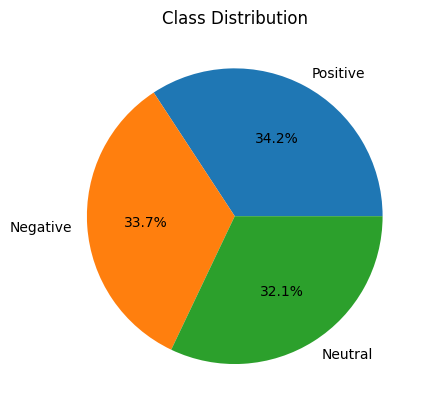

In [ ]:
class_counts = df['sentiment'].value_counts()
class_percents = class_counts / class_counts.sum() * 100
# Plot the pie chart
plt.pie(class_percents, labels=class_counts.index, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.savefig("my_plot.png")
plt.show()

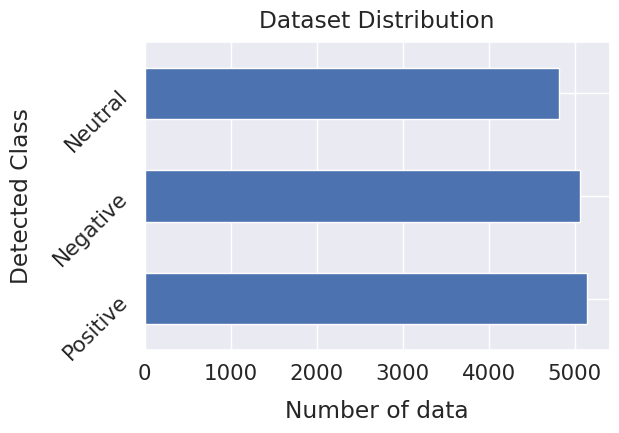

In [ ]:
sns.set(font_scale=1.4)
df['sentiment'].value_counts().plot(kind='barh', figsize=(6, 4))
plt.xlabel("Number of data", labelpad=12)
plt.ylabel("Detected Class", labelpad=12)
plt.yticks(rotation = 45)
plt.title("Dataset Distribution", y=1.02);
plt.savefig("Dataset Distribution BarChart.png")

In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


# **Data Preprocessing and Cleaning**

In [ ]:
df.drop_duplicates(inplace=True)

# **Lower Case**

In [ ]:
df["Lower_Case"] = df["review"].str.lower()
df.head()

,review,sentiment,Lower_Case
0,Two companies have given shoes,Negative,two companies have given shoes
1,Keeps warm and uncomfortable at times,Neutral,keeps warm and uncomfortable at times
2,"I ordered 2 ton size, got that size,, my AC si...",Positive,"i ordered 2 ton size, got that size,, my ac si..."
3,So far so good. What kind of service is given ...,Negative,so far so good. what kind of service is given ...
4,very bad,Negative,very bad


# **Stopwords Removal**

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import string
from nltk.corpus import stopwords

def process_text(text):
    no_punc = [char for char in text if char not in string.punctuation]
    no_punc = ''.join(no_punc)


    return ' '.join([word for word in no_punc.split() if word.lower() not in stopwords.words('english')])

In [ ]:
df['Stopwords']=df['Lower_Case'].apply(process_text)

In [ ]:
df.head()

,review,sentiment,Lower_Case,Stopwords
0,Two companies have given shoes,Negative,two companies have given shoes,two companies given shoes
1,Keeps warm and uncomfortable at times,Neutral,keeps warm and uncomfortable at times,keeps warm uncomfortable times
2,"I ordered 2 ton size, got that size,, my AC si...",Positive,"i ordered 2 ton size, got that size,, my ac si...",ordered 2 ton size got size ac size 15 ton ord...
3,So far so good. What kind of service is given ...,Negative,so far so good. what kind of service is given ...,far good kind service given later real issue h...
4,very bad,Negative,very bad,bad


In [ ]:
df=df.drop(["review","Lower_Case"],axis=1)

# **Small Text Remove**

In [ ]:
df['length'] = df['Stopwords'].apply(lambda x:len(x.split()))

dataset = df.loc[df.length>0]
dataset = dataset.reset_index(drop = True)
print("After Cleaning:","\nRemoved {} Small conversations".format(len(df)-len(dataset)),
      "\nTotal conversations:",len(dataset))

dataset['no_char'] = df['Stopwords'].apply(lambda cleaned: len(cleaned))

After Cleaning: 
Removed 2 Small conversations 
Total conversations: 14743


In [ ]:
dataset

,sentiment,Stopwords,length,no_char
0,Negative,two companies given shoes,4,25.0
1,Neutral,keeps warm uncomfortable times,4,30.0
2,Positive,ordered 2 ton size got size ac size 15 ton ord...,23,122.0
3,Negative,far good kind service given later real issue h...,13,81.0
4,Negative,bad,1,3.0
...,...,...,...,...
14738,Positive,thank daraj good product,4,66.0
14739,Negative,stuff doesnt burn,3,166.0
14740,Neutral,helps child learn language limited vocabulary,6,33.0
14741,Positive,good 100,2,34.0


# **Stemming**

In [ ]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def stemming (text):
    return ''.join([stemmer.stem(word) for word in text])

In [ ]:
df['Cleantext']=df['Stopwords'].apply(stemming)

In [ ]:
df=df.drop(["Stopwords","length"],axis=1)

In [ ]:
df.head()

,sentiment,Cleantext
0,Negative,two companies given shoes
1,Neutral,keeps warm uncomfortable times
2,Positive,ordered 2 ton size got size ac size 15 ton ord...
3,Negative,far good kind service given later real issue h...
4,Negative,bad


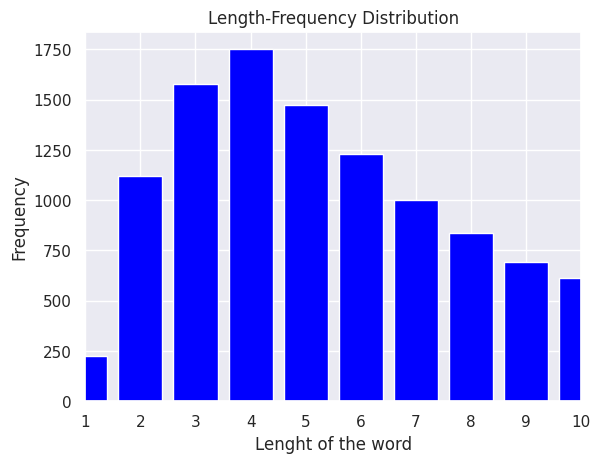

Maximum Length of a comment: 150
Minimum Length of a comment: 1
Average Length of a comment: 9.0


In [ ]:
frequency = dict()
for i in dataset.length:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 10)

plt.xlabel('Lenght of the word')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.length)}")
print(f"Minimum Length of a comment: {min(dataset.length)}")
print(f"Average Length of a comment: {round(np.mean(dataset.length),0)}")

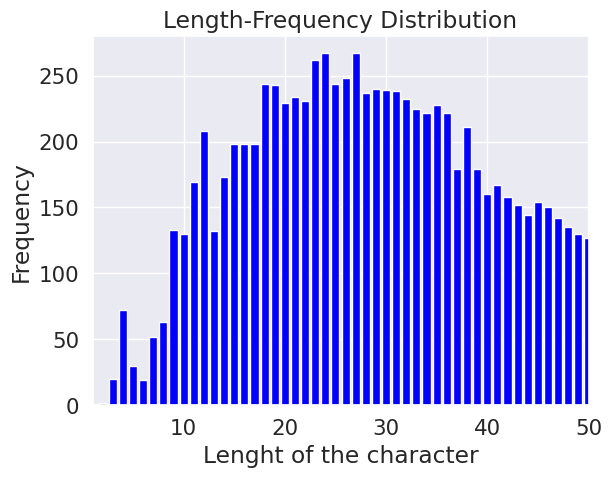

Maximum Length of a comment: 748.0
Minimum Length of a comment: 0.0
Average Length of a comment: 58.0


<Figure size 640x480 with 0 Axes>

In [ ]:
frequency = dict()
for i in dataset.no_char:
    frequency[i] = frequency.get(i, 0)+1

plt.bar(frequency.keys(), frequency.values(), color ="blue")
plt.xlim(1, 50)

plt.xlabel('Lenght of the character')
plt.ylabel('Frequency')
plt.title('Length-Frequency Distribution')
plt.show()
print(f"Maximum Length of a comment: {max(dataset.no_char)}")
print(f"Minimum Length of a comment: {min(dataset.no_char)}")
print(f"Average Length of a comment: {round(np.mean(dataset.no_char),0)}")
plt.savefig("Character Frequency Distribution Bangla BarChart.png")

# **Dataset Summary**

In [ ]:
def data_summary(df):
    reviews = []
    words = []
    u_words = []
    total_u_words = [word.strip().lower() for t in list(df.Cleantext) for word in t.strip().split()]
    class_label= [k for k,v in df.sentiment.value_counts().to_dict().items()]
    for label in class_label:
        word_list = [word.strip().lower() for t in list(df[df.sentiment==label].Cleantext) for word in t.strip().split()]
        counts = dict()
        for word in word_list:
                counts[word] = counts.get(word, 0)+1
        ordered = sorted(counts.items(), key= lambda item: item[1],reverse = True)
        reviews.append(len(list(df[df.sentiment==label].Cleantext)))
        words.append(len(word_list))
        u_words.append(len(np.unique(word_list)))
        print("\nClass Name : ",label)
        print("Number of Comments:{}".format(len(list(df[df.sentiment==label].Cleantext))))
        print("Number of Words:{}".format(len(word_list)))
        print("Number of Unique Words:{}".format(len(np.unique(word_list))))
        print("Most Frequent Words:\n")
        for k,v in ordered[:10]:
              print("{}\t{}".format(k,v))
    print("Total Number of Unique Words:{}".format(len(np.unique(total_u_words))))

    return reviews,words,u_words,class_label

#call the fucntion
reviews,words,u_words,class_names = data_summary(df)


Class Name :  Positive
Number of Comments:5012
Number of Words:54771
Number of Unique Words:4185
Most Frequent Words:

good	3877
product	2231
alhamdulillah	1502
thanks	1245
take	1238
price	1008
got	1007
seller	943
thank	908
received	828

Class Name :  Negative
Number of Comments:4960
Number of Words:43769
Number of Unique Words:4711
Most Frequent Words:

product	1198
one	1123
bad	1103
good	828
quality	655
gave	555
color	532
give	475
dont	461
ordered	453

Class Name :  Neutral
Number of Comments:4773
Number of Words:34807
Number of Unique Words:4413
Most Frequent Words:

good	1771
price	777
product	634
quality	614
little	353
better	328
color	309
bad	306
bit	291
take	282
Total Number of Unique Words:8569


In [ ]:
data_matrix = pd.DataFrame({'Total comments':reviews,
                            'Total Words':words,
                            'Unique Words':u_words,
                            'Class Names':class_names})
data = pd.melt(data_matrix, id_vars="Class Names", var_name="Category", value_name="Values")

In [ ]:
data

,Class Names,Category,Values
0,Positive,Total comments,5012
1,Negative,Total comments,4960
2,Neutral,Total comments,4773
3,Positive,Total Words,54771
4,Negative,Total Words,43769
5,Neutral,Total Words,34807
6,Positive,Unique Words,4185
7,Negative,Unique Words,4711
8,Neutral,Unique Words,4413


# **Data Summary Visualization**

/tmp/ipython-input-1337874303.py:8: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



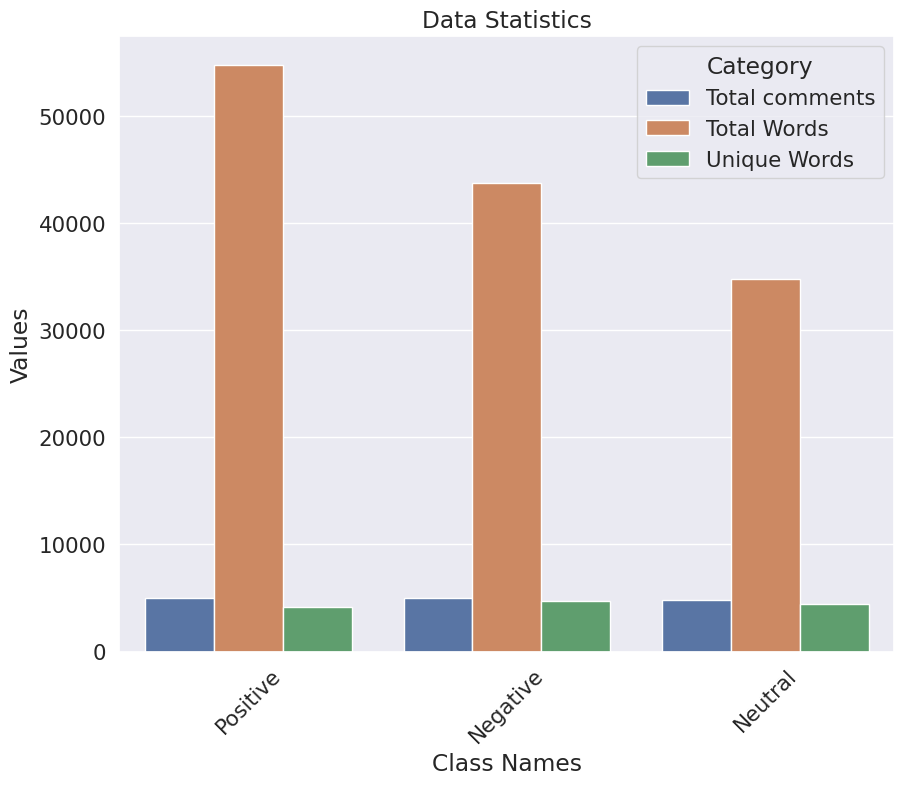

In [ ]:
plt.figure(figsize=(10, 8))
ax = plt.subplot()

sns.barplot(data=data,x='Class Names', y='Values' ,hue='Category')
ax.set_xlabel('Class Names')
ax.set_title('Data Statistics')

ax.xaxis.set_ticklabels(class_names, rotation=45);

plt.savefig("Data Statistics Bangla BarChart.png")

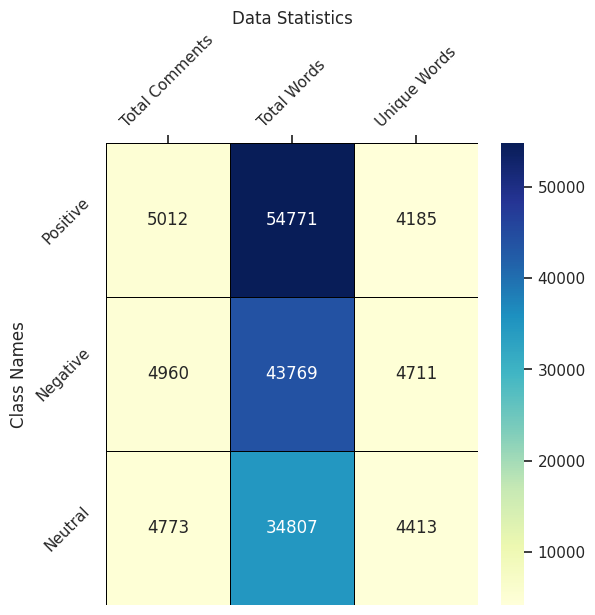

In [ ]:
sns.set()
plt.figure(figsize =(6, 6))
ax = plt.subplot()
sns.heatmap(data_matrix.iloc[:,0:3], annot=True,fmt="d", linewidths=0.5,linecolor = 'Black',cmap = "YlGnBu",ax = ax)

ax.set_ylabel('Class Names')
ax.set_title('Data Statistics')
y_label = ["Total Comments", "Total Words", "Unique Words"]
ax.xaxis.set_ticklabels(y_label, rotation=45); ax.yaxis.set_ticklabels(class_names, rotation=45);
ax.xaxis.tick_top()
plt.savefig("Data Statistics Bangla.png")

In [ ]:
sample_data=[10,100]
class color: # Text style
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

In [ ]:
df.head()

,sentiment,Cleantext
0,Negative,two companies given shoes
1,Neutral,keeps warm uncomfortable times
2,Positive,ordered 2 ton size got size ac size 15 ton ord...
3,Negative,far good kind service given later real issue h...
4,Negative,bad


# **Data Encoding Function**

In [ ]:
import keras
import tensorflow
import pickle
from tensorflow.keras.preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences as pad
from sklearn.preprocessing import LabelEncoder

In [ ]:
def label_encoding(df,bool):
  '''
  This function will convert categorical class names into a numeric label
  '''
  le = LabelEncoder()
  le.fit(df.sentiment)
  encoded_labels = le.transform(df.sentiment)
  labels = np.array(encoded_labels) # Converting into numpy array
  class_names =le.classes_ ## Define the class names again
  if bool == True:
    print(color.BOLD+"\n\t\t\t===== Label Encoding ====="+color.END,"\nClass Names:-->",le.classes_)
  return labels
def dataset_split(news,Label):
  '''
  This function will split the dataset into Train-Test-Validation set
  '''

  X,X_test,y,y_test = train_test_split(news,Label,train_size = 0.8,
                                                  test_size = 0.2,random_state =0)
  X_train,X_valid,y_train,y_valid = train_test_split(X,y,train_size = 0.8,
                                                  test_size = 0.2,random_state =0)
  print(color.BOLD+"Feature Size :======>"+color.END,X_train.shape[1])
  print(color.BOLD+"\nDataset Distribution:\n"+color.END)
  print("\tSet Name","\t\tSize")
  print("\t========\t\t======")

  print("\tFull\t\t\t",news.shape[0],
        "\n\tTraining\t\t",X_train.shape[0],
        "\n\tTest\t\t\t",X_test.shape[0],
        "\n\tValidation\t\t",X_valid.shape[0])

  return X_train,X_valid,X_test,y_train,y_valid,y_test

In [ ]:
def encoded_texts(dataset, padding_length, max_words):
    from tensorflow.keras.preprocessing.text import Tokenizer
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from sklearn.preprocessing import LabelEncoder
    import pickle
    import numpy as np

    # Initialize tokenizer
    tokenizer = Tokenizer(
        num_words=max_words,
        filters='!"#$%&()*+,-./:;<=>?@[\]^_`{|}~\t\n-',
        split=' ',
        char_level=False,
        oov_token='<OOV>',  # Added OOV token for better handling
        document_count=0
    )

    # Fit on texts - ensure we're using the correct column
    tokenizer.fit_on_texts(dataset['Cleantext'].astype(str))  # Convert to string to avoid numpy unicode issues

    # Get tokenizer attributes
    word_counts = tokenizer.word_counts
    word_docs = tokenizer.word_docs
    word_index = tokenizer.word_index
    document_count = tokenizer.document_count

    def tokenizer_info(mylist, reverse=True):
        """Helper function to display tokenizer info"""
        ordered = sorted(mylist.items(), key=lambda item: item[1], reverse=reverse)
        for w, c in ordered[:10]:
            print(f"{w}\t{c}")

    print("\n\t\t\t====== Tokenizer Info ======")
    print("Words --> Counts:")
    tokenizer_info(word_counts, True)
    print("\nWords --> Documents:")
    tokenizer_info(word_docs, True)
    print("\nWords --> Index:")
    tokenizer_info(word_index, False)  # Show index in order
    print(f"\nTotal Documents --> {document_count}")

    # Convert string into list of integer indices
    sequences = tokenizer.texts_to_sequences(dataset['Cleantext'].astype(str))  # Convert to string
    print(f"\n\t\t\t====== Encoded Sequences ======\nFound {len(word_index)} unique tokens")
    print(f"Sample text: {dataset['Cleantext'].iloc[10]}")
    print(f"Encoded: {sequences[10]}")

    # Pad Sequences
    corpus = pad_sequences(
        sequences,
        value=0.0,
        padding='post',
        maxlen=padding_length
    )
    print("\n\t\t\t====== Padded Sequences ======")
    print(f"Sample text: {dataset['Cleantext'].iloc[10]}")
    print(f"Padded: {corpus[10]}")

    # Label Encoding - Fixed version
    def label_encoding(data, verbose=False):
        """Fixed label encoding function"""
        le = LabelEncoder()

        # Ensure we're working with strings and handle NaN values
        sentiments = data['sentiment'].astype(str).fillna('unknown')
        encoded_labels = le.fit_transform(sentiments)

        if verbose:
            print("\n\t\t\t===== Label Encoding =====")
            print("Class Names:", le.classes_)
            print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

            # Show sample encoding
            sample_indices = [0, 1, 2]  # First few samples
            for i in sample_indices:
                if i < len(data):
                    print(f"'{data['sentiment'].iloc[i]}' -> {encoded_labels[i]}")

        return encoded_labels, le

    labels, label_encoder = label_encoding(dataset, True)

    # Save the tokenizer
    with open('tokenizer.pickle', 'wb') as handle:
        pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

    # Save label encoder
    with open('label_encoder.pickle', 'wb') as handle:
        pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)

    return corpus, labels, tokenizer, label_encoder

# Call the function with proper error handling
try:
    num_words = 5000
    corpus, labels, tokenizer, label_encoder = encoded_texts(df, 300, num_words)
    print(f"\nShape of Encoded Corpus: {corpus.shape}")
    print(f"Shape of Labels: {labels.shape}")

except Exception as e:
    print(f"Error: {e}")
    print("Trying alternative approach...")

    # Alternative approach if the main one fails
    corpus, labels = encoded_texts_safe(df, 300, 5000)

<>:11: SyntaxWarning:

invalid escape sequence '\]'

<>:11: SyntaxWarning:

invalid escape sequence '\]'

/tmp/ipython-input-1485390458.py:11: SyntaxWarning:

invalid escape sequence '\]'




			====== Tokenizer Info ======
Words --> Counts:
good	6476
product	4063
price	2139
quality	2024
take	1830
one	1634
alhamdulillah	1607
bad	1463
got	1425
thanks	1368

Words --> Documents:
good	5083
product	3253
price	1954
quality	1856
take	1711
alhamdulillah	1526
one	1328
got	1325
bad	1320
thanks	1247

Words --> Index:
<OOV>	1
good	2
product	3
price	4
quality	5
take	6
one	7
alhamdulillah	8
bad	9
got	10

Total Documents --> 14745

			====== Encoded Sequences ======
Found 8570 unique tokens
Sample text: ordered transparent case silicone cheap batman case shipped
Encoded: [22, 2552, 453, 1164, 409, 4235, 453, 1569]

			====== Padded Sequences ======
Sample text: ordered transparent case silicone cheap batman case shipped
Padded: [  22 2552  453 1164  409 4235  453 1569    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0 

# **Data Splitting Function**

In [ ]:
#Call Dataset Split Function
X_train,X_valid,X_test,y_train,y_valid,y_test = dataset_split(corpus,labels)

Feature Size :======> 300

Dataset Distribution:

	Set Name 		Size
	========		======
	Full			 14745 
	Training		 9436 
	Test			 2949 
	Validation		 2360


In [ ]:
import tensorflow as tf
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

# **Unigram Tf-idf value calculation**

In [2]:
def calc_gram_tfidf(Conversations):
    tfidf = TfidfVectorizer(ngram_range=(1,3),use_idf=True,tokenizer=lambda x: x.split())
    X = tfidf.fit_transform(Conversations)

    return tfidf,X

# **Unigram**

In [3]:
x = ["Keeps warm and uncomfortable at times"]

def get_top_n_words(x, n):
    vec = CountVectorizer().fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]

get_top_n_words(x,3)

[('keeps', np.int64(1)), ('warm', np.int64(1)), ('and', np.int64(1))]

# **Bigram**

In [4]:
y = ["Keeps warm and uncomfortable at times"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(2, 2)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(y,3)

[('keeps warm', np.int64(1)),
 ('warm and', np.int64(1)),
 ('and uncomfortable', np.int64(1))]

# **Trigram**

In [5]:
z = ["Keeps warm and uncomfortable at times"]
def get_top_n_words(x, n):
    vec = CountVectorizer(ngram_range=(3, 3)).fit(x)
    bow = vec.transform(x)
    sum_words = bow.sum(axis = 0)
    words_freq = [(word, sum_words[0,idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key = lambda x: x[1], reverse = True)
    return words_freq[:n]
get_top_n_words(z,3)

[('keeps warm and', np.int64(1)),
 ('warm and uncomfortable', np.int64(1)),
 ('and uncomfortable at', np.int64(1))]

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# **Tokenization**

In [ ]:
max_features = 2500
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(df['Cleantext'].values)
X = tokenizer.texts_to_sequences(df['Cleantext'].values)
X = pad_sequences(X)

In [ ]:
X

array([[   0,    0,    0, ...,   53,   40,  101],
       [   0,    0,    0, ...,  791,  883,  299],
       [   0,    0,    0, ...,   48,   15,   16],
       ...,
       [   0,    0,    0, ..., 1624, 1259,  343],
       [   0,    0,    0, ...,    0,    1,  140],
       [   0,    0,    0, ...,   45,   36,   18]], dtype=int32)

In [ ]:
np.shape(X)

(14745, 149)

# **Model Implementation**

In [ ]:
df.head()

,sentiment,Cleantext
0,Negative,two companies given shoes
1,Neutral,keeps warm uncomfortable times
2,Positive,ordered 2 ton size got size ac size 15 ton ord...
3,Negative,far good kind service given later real issue h...
4,Negative,bad


In [ ]:
X.shape

(14745, 149)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Bidirectional, Dropout

embed_dim = 64
model = Sequential()
model.add(Embedding(input_dim=max_features, output_dim=embed_dim, input_length=X.shape[1]))
model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=False))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, X.shape[1]))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning:

Argument `input_length` is deprecated. Just remove it.



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 149, 64)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,435 (822.01 KB)

 Trainable params: 210,435 (822.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Y = pd.get_dummies(df['sentiment']).values
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2,random_state = 42)
print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

(11796, 149) (11796, 3)
(2949, 149) (2949, 3)


In [ ]:
history=model.fit(X_train, Y_train, epochs = 50, batch_size=32, verbose = 1,validation_data=(X_test,Y_test))

Epoch 1/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 68s 171ms/step - accuracy: 0.5787 - loss: 0.8519 - val_accuracy: 0.8111 - val_loss: 0.4657
Epoch 2/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 169ms/step - accuracy: 0.8247 - loss: 0.4473 - val_accuracy: 0.8227 - val_loss: 0.4387
Epoch 3/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - accuracy: 0.8576 - loss: 0.3729 - val_accuracy: 0.8227 - val_loss: 0.4561
Epoch 4/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 83s 169ms/step - accuracy: 0.8721 - loss: 0.3374 - val_accuracy: 0.8210 - val_loss: 0.4934
Epoch 5/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 83s 172ms/step - accuracy: 0.8770 - loss: 0.3134 - val_accuracy: 0.8155 - val_loss: 0.5090
Epoch 6/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 64s 173ms/step - accuracy: 0.8916 - loss: 0.2854 - val_accuracy: 0.8135 - val_loss: 0.5283
Epoch 7/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 81s 169ms/step - accuracy: 0.9012 - loss: 0.2539 - val_accuracy: 0.8101 - val_loss: 0.5927
Epoch 8/50
369/369 ━━━━━━━━━━━━━━━━━━━━ 62s 169ms/step - accuracy: 0.9094 - loss: 0

In [ ]:
import tensorflow as tf

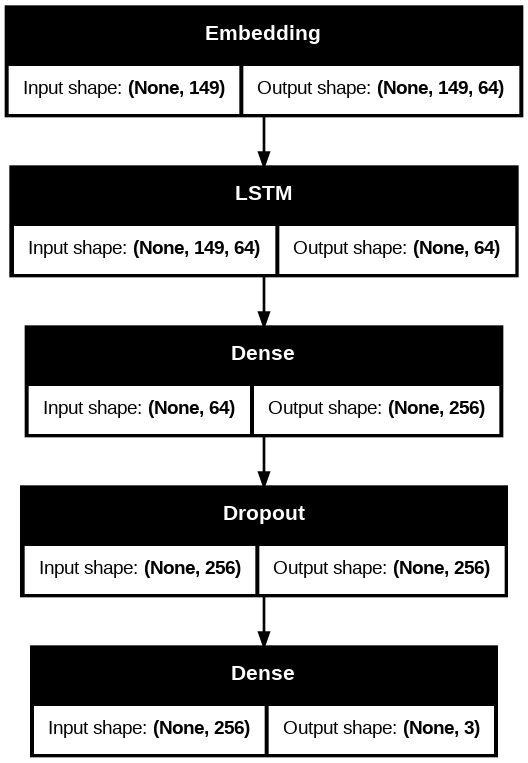

In [ ]:
from tensorflow.keras.utils import plot_model

# Save the model architecture plot
plot_model(
    model,
    to_file='model_architecture2.png',  # ✅ Specify output file
    show_shapes=True,
    dpi=96  # Adjust resolution
)

# **Evaluation**

In [ ]:
score = model.evaluate(X_train, Y_train,batch_size=64, verbose=2)
print('Train loss:', score[0])
print('Train accuracy:', score[1])

185/185 - 15s - 80ms/step - accuracy: 0.9815 - loss: 0.0411
Train loss: 0.04105044901371002
Train accuracy: 0.9815191626548767


In [ ]:
score = model.evaluate(X_test, Y_test,batch_size=64, verbose=2)
print('Test loss:', score[0])
acc=score[1]
print('Test accuracy:', acc)

47/47 - 2s - 36ms/step - accuracy: 0.7850 - loss: 1.7675
Test loss: 1.7674678564071655
Test accuracy: 0.785011887550354


# **Learning Curve**

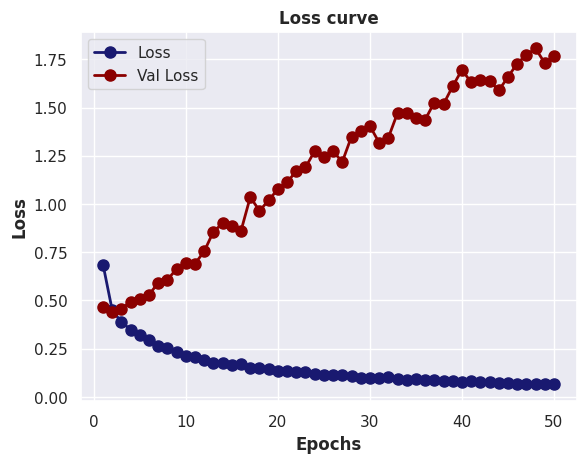

In [ ]:
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(1, len(acc) + 1)
sns.set_style('darkgrid')


plt.plot(epochs, loss_values, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_loss_values, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Loss curve',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Loss',fontsize=12,fontweight='bold')
plt.legend(['Loss','Val Loss'])

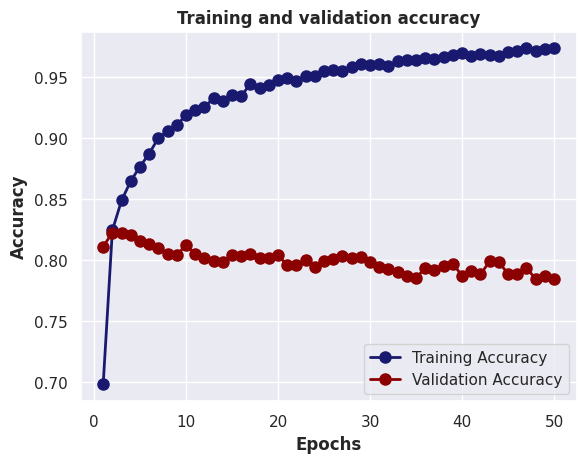

In [ ]:
plt.plot(epochs, acc, color='midnightblue', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.plot(epochs, val_acc, color='darkred', linewidth = 2,
          marker='o', markersize=8,label='Training Accuracy')
plt.title('Training and validation accuracy',fontsize=12,fontweight='bold')
plt.xlabel('Epochs',fontsize=12,fontweight='bold')
plt.ylabel('Accuracy',fontsize=12,fontweight='bold')
plt.legend(['Training Accuracy','Validation Accuracy'])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


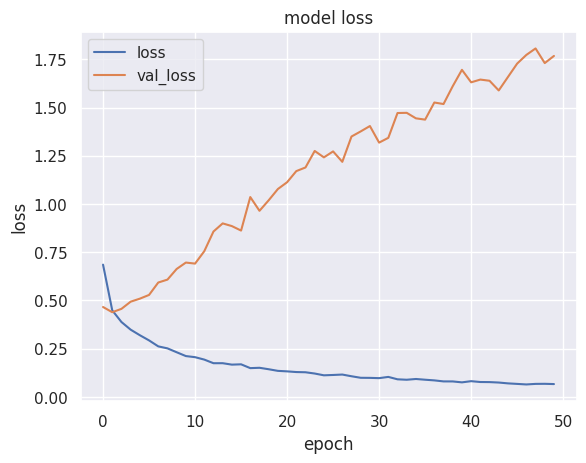

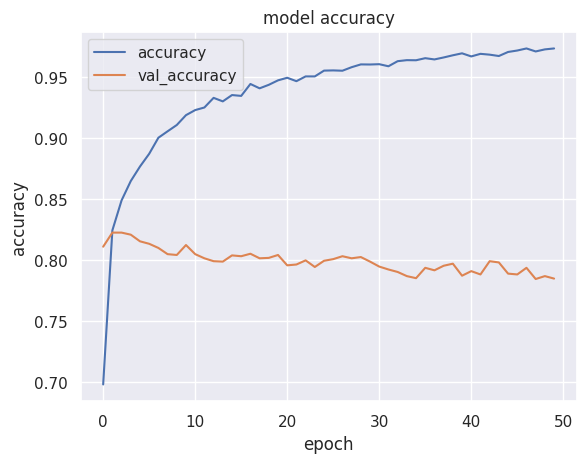

In [ ]:
print(history.history.keys())
loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(loss)
plt.plot(val_loss)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss', 'val_loss'])
plt.show()

accuracy = history.history['accuracy']
val_accuracy= history.history['val_accuracy']
plt.plot(accuracy)
plt.plot(val_accuracy)
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy', 'val_accuracy'])
plt.show()

# **Confusion Matrix & Classification Report**

In [ ]:
X_train.shape,Y_train.shape,X_test.shape,Y_test.shape

((11796, 149), (11796, 3), (2949, 149), (2949, 3))

In [ ]:
y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred, axis=1)
y_test=np.argmax(Y_test, axis=1)
cm = confusion_matrix(y_test, y_pred)
print(cm)

93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 76ms/step
[[772 146  49]
 [164 681 105]
 [ 64 106 862]]


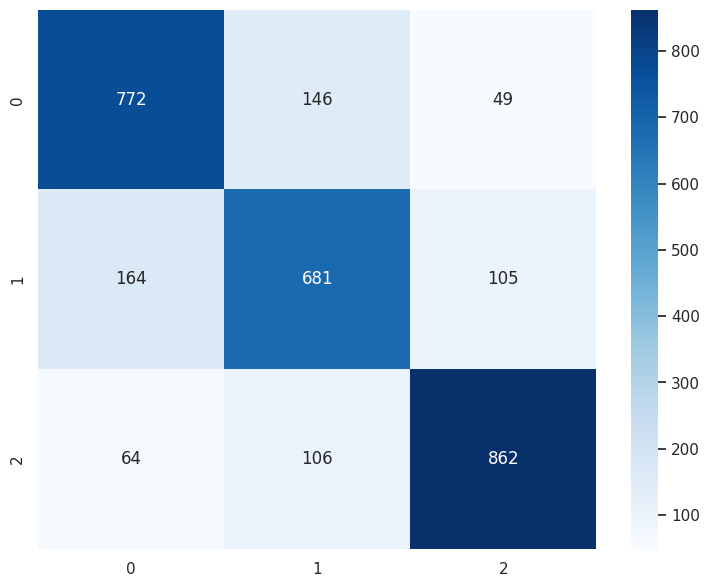

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm,cmap='Blues', annot=True,fmt='d')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
report = pd.DataFrame(classification_report(y_test, y_pred,output_dict=True)).transpose()

In [ ]:
report = report.rename(index={'0': 'Positive','1':'Negative','2':'Neutral'})
report[['precision','recall','f1-score']]=report[['precision','recall','f1-score']].apply(lambda x: round(x*100,2))

In [ ]:
report

,precision,recall,f1-score,support
Positive,7720.0,7983.0,7850.0,967.000000
Negative,7299.0,7168.0,7233.0,950.000000
Neutral,8484.0,8353.0,8418.0,1032.000000
accuracy,7850.0,7850.0,7850.0,0.785012
macro avg,7834.0,7835.0,7834.0,2949.000000
weighted avg,7852.0,7850.0,7850.0,2949.000000


# **Output Analysis**

In [ ]:
twt = ['It does not work, not recommended']
twt = tokenizer.texts_to_sequences(twt)
twt = pad_sequences(twt, maxlen=28, dtype='int32', value=0)
print(twt)
sentiment = model.predict(twt,batch_size=1,verbose = 2)[0]
if(np.argmax(sentiment) == 0):
    print("Positive")
elif (np.argmax(sentiment) == 1):
    print("Negative")
elif (np.argmax(sentiment) == 2):
    print("Neutral")

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0  65 480]]
1/1 - 0s - 72ms/step
Negative
